In [1]:
from tqdm import tqdm
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np

import warnings, os
import mysql.connector as mysql
warnings.filterwarnings('ignore')
username = os.environ['MYSQL_user']
password = os.environ['MYSQL_password']
DB = mysql.connect(host = "localhost", user = username, passwd = password, database = "AIRBNB")
cursor = DB.cursor(buffered=True)

## Utils

In [2]:
def read_table_from_db(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', con=DB)
    return df

In [3]:
def bytes_to_image(bytes_image: bytes) -> np.ndarray:
    """
    Function that converts bytes to an image.
    
    Args:
        bytes_image (bytes): Bytes of the image.
    
    Returns:
        np.ndarray: Image.
    """
    image = cv2.imdecode(np.frombuffer(bytes_image, np.uint8), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [4]:
def display_image(image: np.ndarray) -> None:
    """
    Function that displays an image.
    
    Args:
        image (np.ndarray): Image.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Load dataset

In [5]:
table_name = "images"
images_data = read_table_from_db(table_name)
images_color_attributes_data = read_table_from_db("images_color_attributes")
images_data = images_data.merge(images_color_attributes_data, on="id", how="inner")
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted,warmth_hue,saturation,brightness,contrast_brightness,clarity
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0,0.870311,0.156989,0.212105,0.266914,0.096382
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0,0.610155,0.273740,0.545901,0.243398,0.382092
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1,0.173552,0.253439,0.503338,0.267396,0.241613
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1,0.983737,0.265499,0.566499,0.187269,0.356617
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1,0.517305,0.132521,0.540238,0.259135,0.316075
...,...,...,...,...,...,...,...,...,...,...,...,...
382475,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1,0.999763,0.207686,0.786549,0.099478,0.863692
382476,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1,0.762999,0.209219,0.716846,0.129519,0.570378
382477,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1,0.897917,0.400995,0.651478,0.110679,0.381406
382478,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384123,1,0.838707,0.300679,0.559413,0.199620,0.328076


Create columns which will store values for color attributes.

In [12]:
color_attributes = ['warm_hue', 'saturation', 'brightness', 'contrast_brightness', 'clarity']
for color_attribute in color_attributes:
    images_data[color_attribute] = None
    images_data[color_attribute] = images_data[color_attribute].astype('float32')

# Color attributes

In [6]:
class ImageColorAttributes:    
    def calculate_image_attributes(self, image: np.ndarray) -> dict:
        """
        Calculate the image attributes for an image.

        Args:
            image (np.ndarray): An image in RGB color space.
        
        Returns:
            dict: A dictionary containing the image attributes.
        """
        hsv_image = self.convert_to_hsv(image)
        warmth_hue = self.calculate_warm_hue(hsv_image)
        saturation = self.calculate_saturation(hsv_image)
        brightness = self.calculate_brightness(hsv_image)
        contrast_brightness = self.calculate_contrast_brightness(hsv_image, brightness)
        clarity = self.calculate_image_clarity(hsv_image, brightness)
        image_attributes = {
            'warmth_hue': warmth_hue,
            'saturation': saturation,
            'brightness': brightness,
            'contrast_brightness': contrast_brightness,
            'clarity': clarity
        }
        return image_attributes
    
    @staticmethod
    def convert_to_hsv(image: np.ndarray) -> np.ndarray:
        """
        Convert an image from RGB to HSV color space.

        Args:
            image (np.ndarray): An image in RGB color space.
        
        Returns:
            np.ndarray: An image in HSV color space.
        """
        return cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    @staticmethod
    def calculate_warm_hue(hsv_image: np.ndarray) -> float:
        hue = hsv_image[:, :, 0].astype(np.float32)
        hue = hue*2 #Convert hue to 0-360 range
        warm_hue = np.sum((hue <= 60) | (hue >= 300)) / hue.size #Warm hues are 0-60 and 300-360
        return warm_hue
    
    @staticmethod
    def calculate_saturation(hsv_image):
        saturation = hsv_image[:, :, 1]/255
        return np.mean(saturation)
    
    @staticmethod
    def calculate_brightness(hsv_image):
        brightness = hsv_image[:, :, 2]/255
        return np.mean(brightness)
    
    @staticmethod
    def calculate_contrast_brightness(hsv_image, brightness):
        brightness = hsv_image[:, :, 2]/255
        contrast_brightness = np.std(brightness)
        return contrast_brightness
    
    @staticmethod
    def calculate_image_clarity(hsv_image, brightness):
        brightness = hsv_image[:, :, 2]/255
        image_clarity = np.sum((brightness >= 0.7) & (brightness <= 1)) / brightness.size
        return image_clarity

image_color_attributes = ImageColorAttributes()

In [ ]:
with tqdm(
        total=len(images_data),
        unit="images",
        unit_scale=True,
        desc=f"Processing images",
    ) as pbar:
    for index, row in images_data.iterrows():
        bytes_image = row["image"]
        if not bytes_image:
            pbar.update(1)
            continue
        image = bytes_to_image(row['image'])
        image_attributes = image_color_attributes.calculate_image_attributes(image)
        for attribute, value in image_attributes.items():
            images_data.at[index, attribute] = value
        pbar.update(1)
        # if index == 20000:
        #     break

## Warm hue

Warm Hue: 0.999835


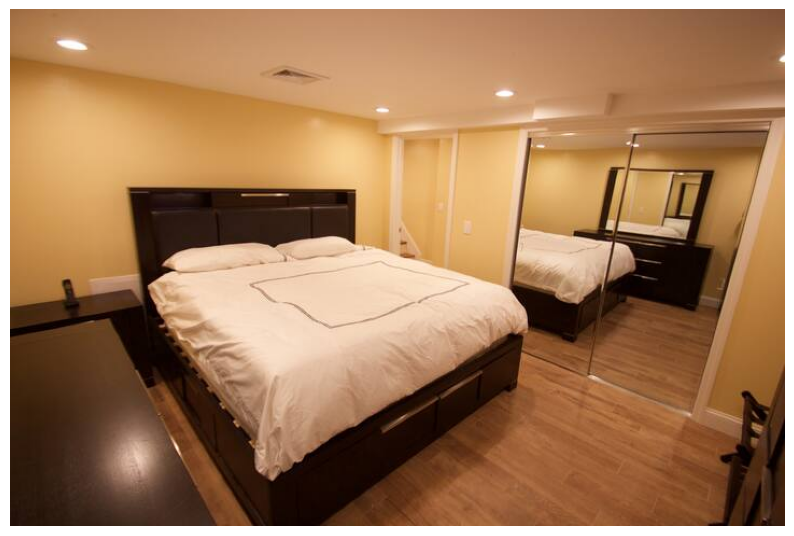

In [24]:
random_row = images_data[(images_data['room_type'] == 'bedroom') & (images_data['warmth_hue'] >= 0.98)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Warm Hue: {random_row['warmth_hue'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/warm_hue_image.png', 'wb') as f:
    f.write(random_bytes_image)

Warm Hue: 0.000112847


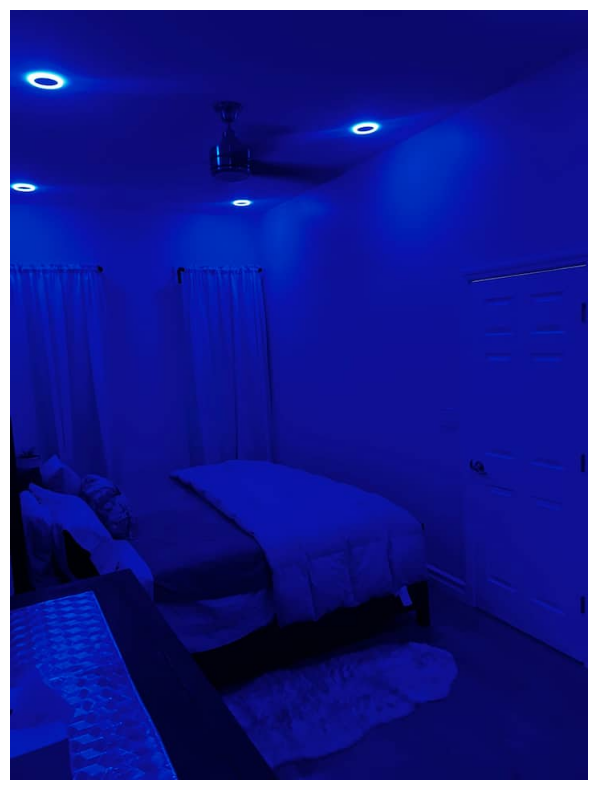

In [122]:
random_row = images_data[(images_data['room_type'] == 'bedroom') & (images_data['warmth_hue'] < 0.01)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Warm Hue: {random_row['warmth_hue'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/cool_hue_image.png', 'wb') as f:
    f.write(random_bytes_image)

## Saturation

Saturation: 0.907153


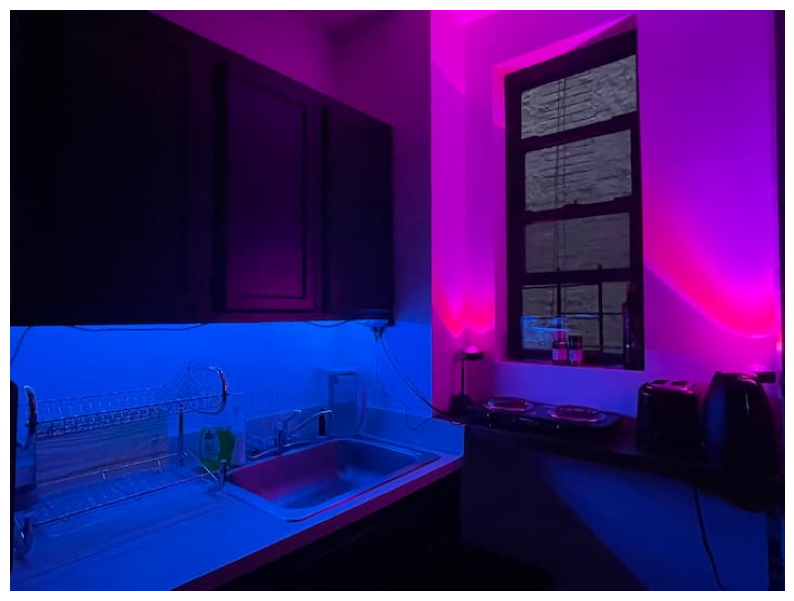

In [127]:
random_row = images_data[(images_data['room_type'] == 'kitchen') & (images_data['saturation'] >= 0.9)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Saturation: {random_row['saturation'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/high_saturation_image.png', 'wb') as f:
    f.write(random_bytes_image)

Saturation: 0.0202169


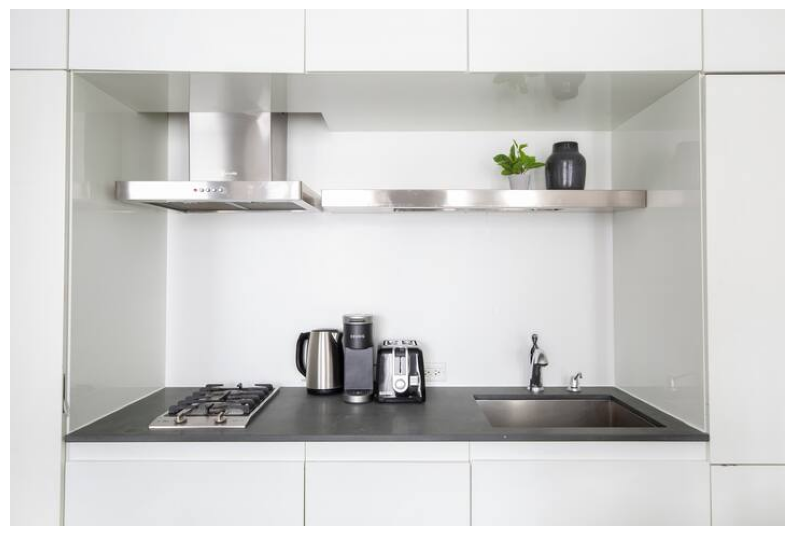

In [148]:
random_row = images_data[(images_data['room_type'] == 'kitchen') & (images_data['saturation'] < 0.05)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Saturation: {random_row['saturation'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/low_saturation_image.png', 'wb') as f:
    f.write(random_bytes_image)

## Brightness

Brightness: 0.950849


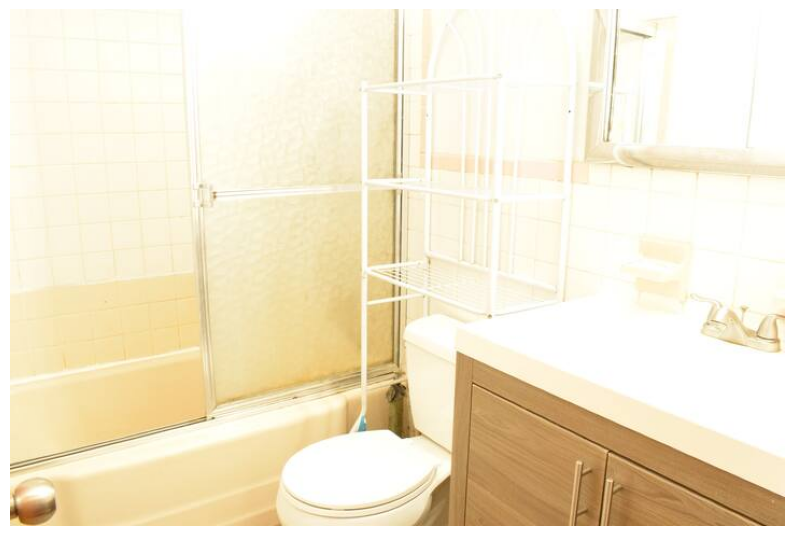

In [209]:
random_row = images_data[(images_data['room_type'] == 'bathroom') & (images_data['brightness'] >= 0.95)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Brightness: {random_row['brightness'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/high_brightness_image.png', 'wb') as f:
    f.write(random_bytes_image)

Brightness: 0.19447


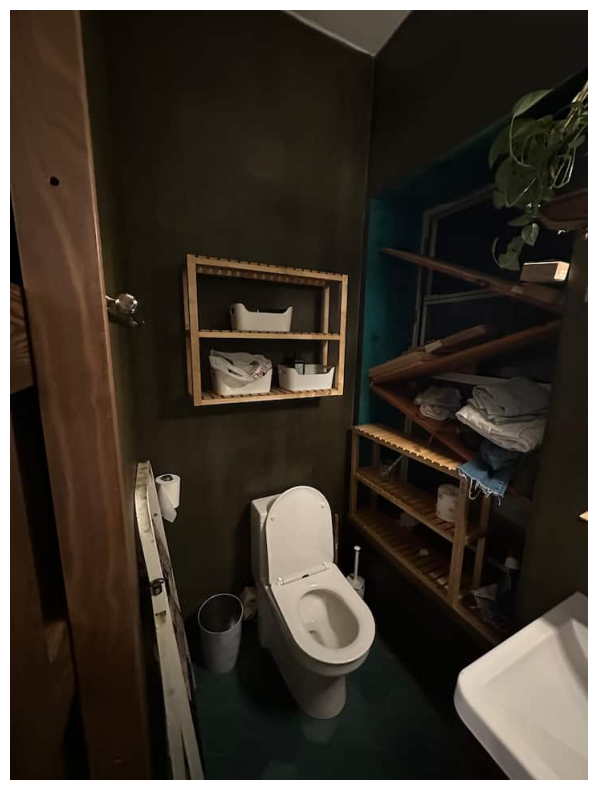

In [225]:
random_row = images_data[(images_data['room_type'] == 'bathroom') & (images_data['brightness'] < 0.2)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Brightness: {random_row['brightness'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/low_brightness_image.png', 'wb') as f:
    f.write(random_bytes_image)

## Contrast Brightness

Contrast Brightness: 0.403033


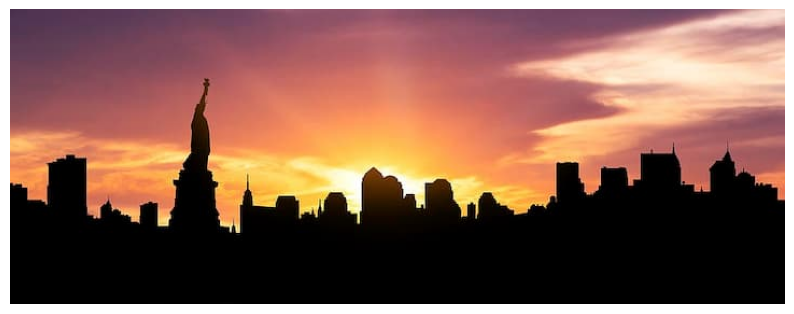

In [234]:
random_row = images_data[(images_data['room_type'] == 'outside_building') & (images_data['contrast_brightness'] >= 0.4)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Contrast Brightness: {random_row['contrast_brightness'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/high_contrast_brightness_image.png', 'wb') as f:
    f.write(random_bytes_image)

Contrast Brightness: 0.0443366


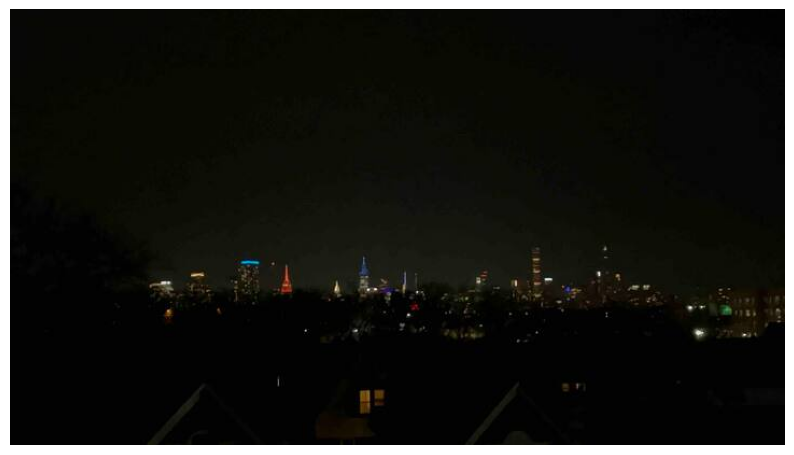

In [245]:
random_row = images_data[(images_data['room_type'] == 'outside_building') & (images_data['contrast_brightness'] < 0.05)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Contrast Brightness: {random_row['contrast_brightness'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/low_contrast_brightness_image.png', 'wb') as f:
    f.write(random_bytes_image)

## Image clarity

Image clarity: 0.959631


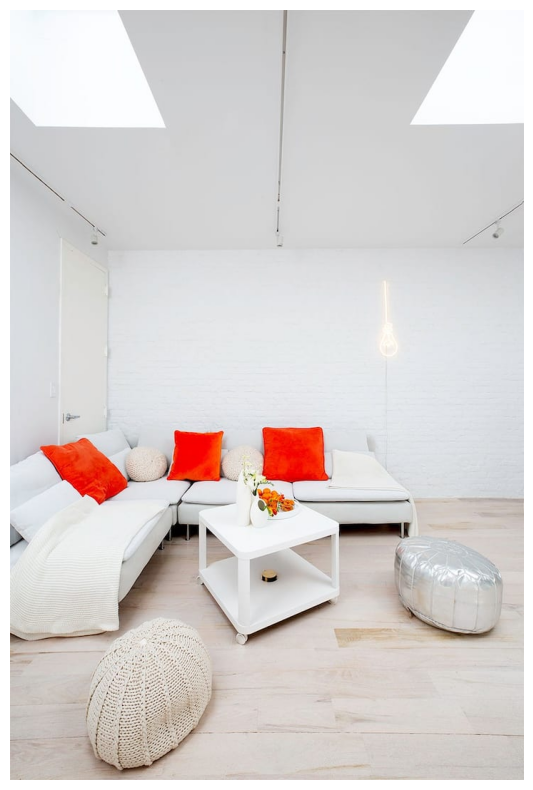

In [296]:
random_row = images_data[(images_data['room_type'] == 'living_room') & (images_data['clarity'] >= 0.95)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Image clarity: {random_row['clarity'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/high_clarity_image.png', 'wb') as f:
    f.write(random_bytes_image)

Image clarity: 0.00996636


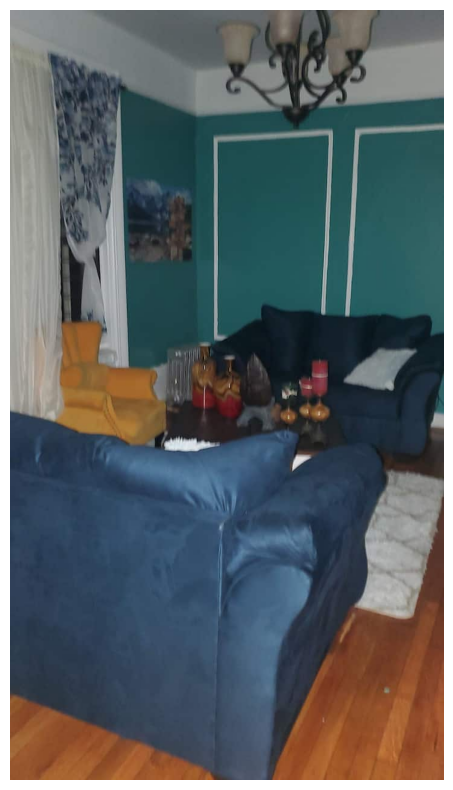

In [448]:
random_row = images_data[(images_data['room_type'] == 'living_room') & (images_data['clarity'] < 0.01)].sample(1)
random_bytes_image = random_row["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
print(f"Image clarity: {random_row['clarity'].values[0]}")
display_image(random_image)
with open('color_attributes_examples/low_clarity_image.png', 'wb') as f:
    f.write(random_bytes_image)

In [ ]:
# cursor.execute("DROP TABLE IF EXISTS images_color_attributes")
# create_table_query = """
# CREATE TABLE images_color_attributes (
#     id INT PRIMARY KEY,
#     warmth_hue FLOAT,
#     saturation FLOAT,
#     brightness FLOAT,
#     contrast_brightness FLOAT,
#     clarity FLOAT
# )
# """
# cursor.execute(create_table_query)
# DB.commit()

In [279]:
insert_query = "INSERT INTO images_color_attributes (id, warmth_hue, saturation, brightness, contrast_brightness, clarity) VALUES (%s, %s, %s, %s, %s, %s)"
for index, row in images_data.iterrows():
    cursor.execute(insert_query, (row['id'], row['warmth_hue'], row['saturation'], row['brightness'], row['contrast_brightness'], row['clarity']))
DB.commit()